In [10]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1)

#### OLS vs Random Intercept Models

In [5]:
# Simulation parameters

n_participants = 30

n_trials = 20

grand_mean = 650

stroop_effect = 70

participant_sd = 70

trial_sd = 35

In [12]:
# Simulating participant baselines.

participant_intercepts = np.random.normal(
    loc=grand_mean,
    scale=participant_sd,
    size=n_participants
)

In [22]:
# Simulating repeated-measures data.

participant = []

condition = []

reaction_time = []

for i in range(n_participants):

    congruent = np.random.normal(
        loc=participant_intercepts[i],
        scale=trial_sd,
        size=n_trials
    )

    incongruent = np.random.normal(
        loc=participant_intercepts[i] + stroop_effect,
        scale=trial_sd,
        size=n_trials
    )

    participant.extend([i + 1] * (2 * n_trials))

    condition.extend(
        ["Congruent"] * n_trials +
        ["Incongruent"] * n_trials
    )

    reaction_time.extend(congruent)

    reaction_time.extend(incongruent)

data = pd.DataFrame({
    "participant": participant,
    "condition": condition,
    "reaction_time": reaction_time
})

In [23]:
# Ordinary Least Squares

ols_model = smf.ols(
    "reaction_time ~ C(condition)",
    data=data
).fit()

In [24]:
# Random Intercept Model

mixed_model = smf.mixedlm(
    "reaction_time ~ C(condition)",
    data=data,
    groups=data["participant"]
).fit()

In [25]:
# Predictions

data["ols_prediction"] = ols_model.predict(data)

data["mixed_prediction"] = mixed_model.predict(data)

In [26]:
# Variance estimates

between_variance = mixed_model.cov_re.iloc[0, 0]

within_variance = mixed_model.scale

In [27]:
# Summary statistics

print("Dataset\n", data.head())

print("\nOLS coefficients\n")
print(ols_model.params)

print("\nRandom intercept model coefficients\n")
print(mixed_model.fe_params)

print("\nVariance estimates")

print("Between-participant variance:", between_variance)

print("Within-participant variance:", within_variance)

print("\nPrediction comparison\n")

print(
    data[
        [
            "participant",
            "condition",
            "reaction_time",
            "ols_prediction",
            "mixed_prediction"
        ]
    ].head(10)
)

print("\nOLS model summary\n")

print(ols_model.summary())

print("\nRandom intercept model summary\n")

print(mixed_model.summary())

Dataset
    participant  condition  reaction_time  ols_prediction  mixed_prediction
0            1  Congruent     610.006968      600.023993        600.023993
1            1  Congruent     568.448547      600.023993        600.023993
2            1  Congruent     563.339352      600.023993        600.023993
3            1  Congruent     568.184129      600.023993        600.023993
4            1  Congruent     602.690781      600.023993        600.023993

OLS coefficients

Intercept                      600.023993
C(condition)[T.Incongruent]     70.784778
dtype: float64

Random intercept model coefficients

Intercept                      600.023993
C(condition)[T.Incongruent]     70.784778
dtype: float64

Variance estimates
Between-participant variance: 3816.837864561621
Within-participant variance: 891.7068720395836

Prediction comparison

   participant  condition  reaction_time  ols_prediction  mixed_prediction
0            1  Congruent     610.006968      600.023993        600.0239

#### Memory Experiment with Repeated Participants

In [28]:
# Simulation parameters

n_participants = 40

n_trials = 25

grand_mean = 600

memory_load_effect = 80

participant_sd = 60

trial_sd = 30

In [29]:
# Simulating participant baselines.

participant_intercepts = np.random.normal(
    loc=grand_mean,
    scale=participant_sd,
    size=n_participants
)

In [30]:
# Simulating repeated observations.

participant = []

memory_load = []

reaction_time = []

for i in range(n_participants):

    low_load = np.random.normal(
        loc=participant_intercepts[i],
        scale=trial_sd,
        size=n_trials
    )

    high_load = np.random.normal(
        loc=participant_intercepts[i] + memory_load_effect,
        scale=trial_sd,
        size=n_trials
    )

    participant.extend([i + 1] * (2 * n_trials))

    memory_load.extend(
        ["Low"] * n_trials +
        ["High"] * n_trials
    )

    reaction_time.extend(low_load)

    reaction_time.extend(high_load)

data = pd.DataFrame({
    "participant": participant,
    "memory_load": memory_load,
    "reaction_time": reaction_time
})

In [32]:
# Ordinary Least Squares

ols_model = smf.ols(
    "reaction_time ~ C(memory_load)",
    data=data
).fit()

In [33]:
# Random Intercept Model

mixed_model = smf.mixedlm(
    "reaction_time ~ C(memory_load)",
    data=data,
    groups=data["participant"]
).fit()

In [34]:
# Predictions

data["ols_prediction"] = ols_model.predict(data)

data["mixed_prediction"] = mixed_model.predict(data)

In [35]:
# Variance estimates

between_variance = mixed_model.cov_re.iloc[0, 0]

within_variance = mixed_model.scale

icc = between_variance / (
    between_variance + within_variance
)

In [37]:
# Participant means

participant_means = (
    data
    .groupby(["participant", "memory_load"])["reaction_time"]
    .mean()
    .unstack()
)

In [38]:
# Summary statistics

print("Dataset\n", data.head())

print("\nNumber of participants:", data["participant"].nunique())

print("\nTrials per participant:", n_trials * 2)

print("\nOLS coefficients\n")

print(ols_model.params)

print("\nRandom intercept fixed effects\n")

print(mixed_model.fe_params)

print("\nVariance estimates")

print("Between-participant variance:", between_variance)

print("Within-participant variance:", within_variance)

print("Intraclass Correlation (ICC):", icc)

print("\nPrediction comparison\n")

print(
    data[
        [
            "participant",
            "memory_load",
            "reaction_time",
            "ols_prediction",
            "mixed_prediction"
        ]
    ].head(10)
)

Dataset
    participant memory_load  reaction_time  ols_prediction  mixed_prediction
0            1         Low     585.087517      605.267261        605.267261
1            1         Low     619.164503      605.267261        605.267261
2            1         Low     618.592202      605.267261        605.267261
3            1         Low     607.784235      605.267261        605.267261
4            1         Low     702.339619      605.267261        605.267261

Number of participants: 40

Trials per participant: 50

OLS coefficients

Intercept                686.086587
C(memory_load)[T.Low]    -80.819327
dtype: float64

Random intercept fixed effects

Intercept                686.086587
C(memory_load)[T.Low]    -80.819327
dtype: float64

Variance estimates
Between-participant variance: 3625.428386833308
Within-participant variance: 918.188546689246
Intraclass Correlation (ICC): 0.7979168226276072

Prediction comparison

   participant memory_load  reaction_time  ols_prediction  mixed_p

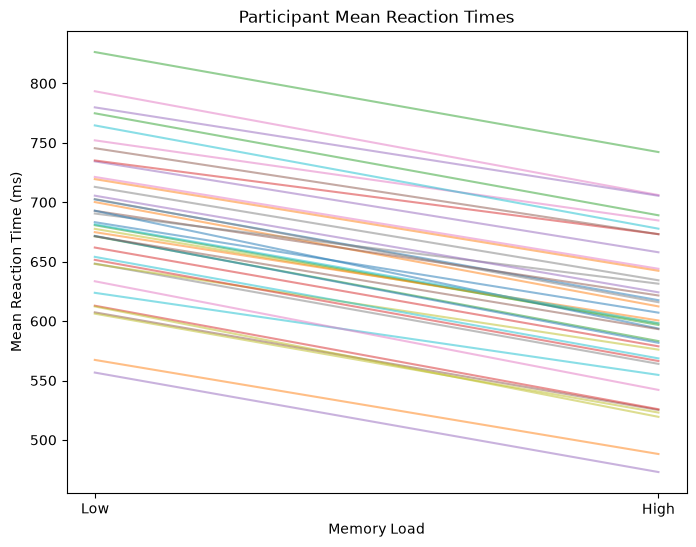

In [40]:
# Visualization

plt.figure(figsize=(8, 6))

for participant_id in participant_means.index:

    plt.plot(
        ["Low", "High"],
        participant_means.loc[participant_id],
        alpha=0.5
    )

plt.xlabel("Memory Load")
plt.ylabel("Mean Reaction Time (ms)")
plt.title("Participant Mean Reaction Times")

plt.show()